# 1. Introducción a Machine Learning: Regresión Logística

En este notebook aprenderás los conceptos básicos de Machine Learning mediante un ejemplo práctico de clasificación usando **regresión logística** y el famoso dataset **Iris**.

## Objetivo

- Comprender los fundamentos de la clasificación supervisada.
- Entrenar y evaluar un modelo de regresión logística.
- Explorar el efecto de la regularización, el escalado y la selección de hiperparámetros.
- Aplicar buenas prácticas: pipelines, validación cruzada y métricas robustas.

## Prerequisitos

> 📌 **Este es el primer notebook del curso.** No se requieren notebooks previos.

**Conocimientos previos recomendados:**
- Python básico (variables, funciones, listas).
- Conceptos básicos de álgebra lineal y estadística.

## 1. Introducción teórica

La **regresión logística** es uno de los algoritmos más clásicos y utilizados para problemas de clasificación. A pesar de su nombre, no realiza regresión: estima la probabilidad de que una muestra pertenezca a una clase usando la función sigmoide.

### ¿Por qué usar regresión logística?
- Es rápida de entrenar y fácil de interpretar.
- Permite obtener probabilidades de pertenencia a cada clase.
- Es robusta ante overfitting si se usa regularización.

**Limitaciones:**
- Solo modela relaciones lineales entre variables y la clase.
- No funciona bien si las clases no son linealmente separables.

> **Nota:** Si la relación real es no lineal, se recomiendan modelos más flexibles como SVM con kernels, árboles de decisión o redes neuronales.

### Parámetros importantes de `LogisticRegression`
- `penalty`: tipo de regularización (`'l1'`, `'l2'`, `'elasticnet'`, `'none'`).
- `C`: inverso de la fuerza de regularización (valores bajos = más regularización).
- `solver`: algoritmo de optimización (`'liblinear'`, `'lbfgs'`, `'saga'`, etc.).
- `max_iter`: número máximo de iteraciones para convergencia.

### ¿Qué es un solver?

Un *solver* es el método matemático que encuentra los valores óptimos de los coeficientes minimizando la función de pérdida.

| Solver | Regularización | Cuándo usarlo |
|--------|---------------|---------------|
| `liblinear` | L1, L2 | Datasets pequeños/medianos, clasificación binaria |
| `lbfgs` | L2 | Datasets medianos, multiclase |
| `saga` | L1, L2, ElasticNet | Datasets grandes o con regularización L1 |
| `newton-cg` | L2 | Multiclase, solo L2 |

**Truco:** Si tu modelo no converge o es muy lento, prueba cambiar el solver o aumentar `max_iter`.

## 2. Importación de librerías

**¿Por qué estas librerías?**
- `numpy` y `pandas`: manipulación eficiente de datos.
- `matplotlib` y `seaborn`: visualización de datos y resultados.
- `sklearn`: librería estándar para machine learning en Python.

**Truco:** Usa `%matplotlib inline` al inicio para ver los gráficos directamente en el notebook.

In [1]:
# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# === Datos y visualización ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Scikit-learn ===
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

%matplotlib inline

## 3. Carga y exploración del dataset

Usaremos el dataset **Iris**, incluido en scikit-learn. Contiene 150 muestras de tres especies de flores (*setosa*, *versicolor*, *virginica*) con 4 variables numéricas por muestra.

In [2]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print(f'Forma del dataset: {X.shape}')
print(f'Clases: {iris.target_names}')
print(f'Distribución de clases:')
print(df['species'].value_counts())
df.head()

Forma del dataset: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Distribución de clases:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**¿Qué buscar en el análisis exploratorio?**
- ¿Hay valores atípicos? ¿Las clases están balanceadas?
- ¿Qué variables parecen más relevantes para separar las clases?

**Truco:** Usa `sns.pairplot` para ver relaciones entre variables y clases rápidamente.

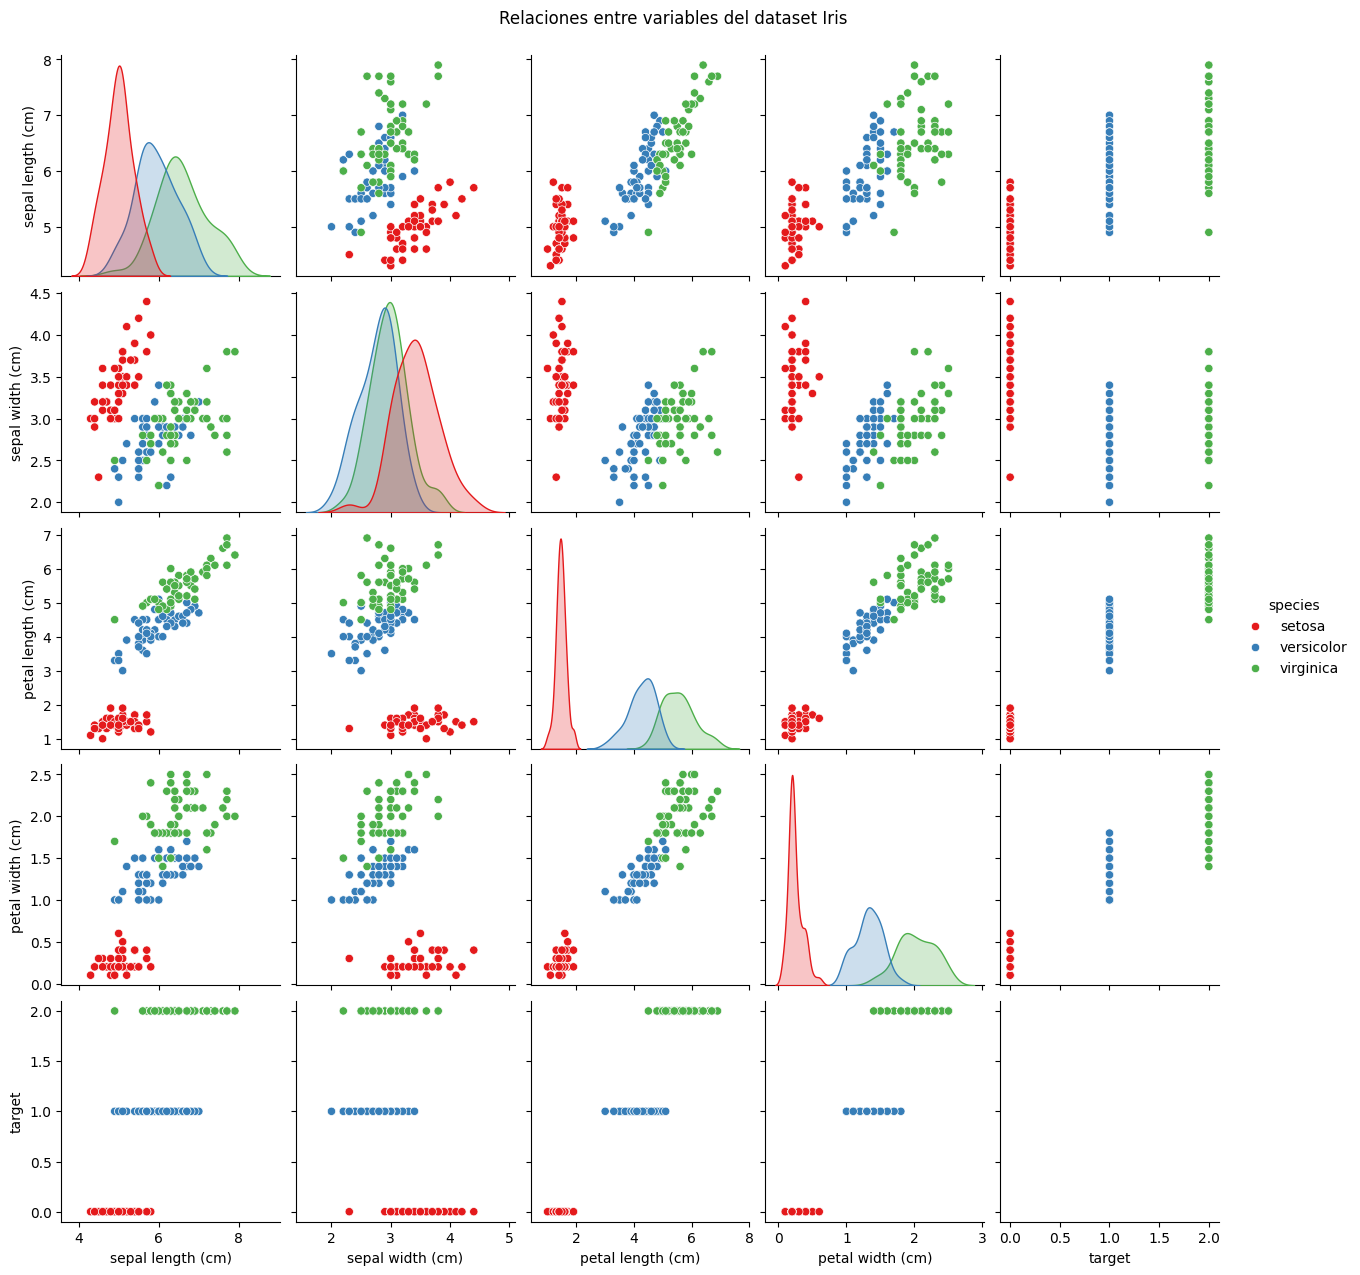

In [3]:
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Relaciones entre variables del dataset Iris', y=1.02)
plt.show()

## 4. División en conjuntos de entrenamiento y prueba

**¿Por qué dividir en train/test?**
- Para evaluar el modelo en datos no vistos y evitar sobreajuste.

**Parámetros importantes:**
- `test_size`: proporción de datos para prueba (0.2 = 20%).
- `random_state`: semilla para reproducibilidad.
- `stratify=y`: mantiene la proporción de clases en ambos conjuntos.

También escalamos las variables con `StandardScaler`, necesario para algunos solvers y que mejora la convergencia del modelo.

In [4]:
# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Escalado de variables (fit SOLO en train para evitar data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Tamaño entrenamiento: {X_train.shape}  |  Tamaño prueba: {X_test.shape}')

Tamaño entrenamiento: (120, 4)  |  Tamaño prueba: (30, 4)


## 5. Construcción y entrenamiento del modelo

Entrenamos un modelo de regresión logística con parámetros por defecto como punto de partida.

In [5]:
model = LogisticRegression(max_iter=200, random_state=SEED)
model.fit(X_train, y_train)
print('Modelo entrenado exitosamente.')
print(f'Coeficientes shape: {model.coef_.shape}  |  Clases: {model.classes_}')

Modelo entrenado exitosamente.
Coeficientes shape: (3, 4)  |  Clases: [0 1 2]


## 6. Evaluación del modelo

**¿Qué métricas mirar?**
- `accuracy_score`: proporción de aciertos.
- `classification_report`: precisión, recall y F1 por clase.
- `confusion_matrix`: errores por clase.

**Truco:** Si tienes clases desbalanceadas, prioriza F1-score o usa `balanced_accuracy_score`.

In [6]:
# Predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9667

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



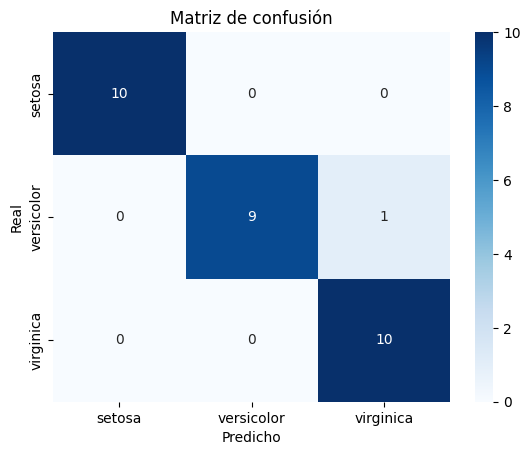

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

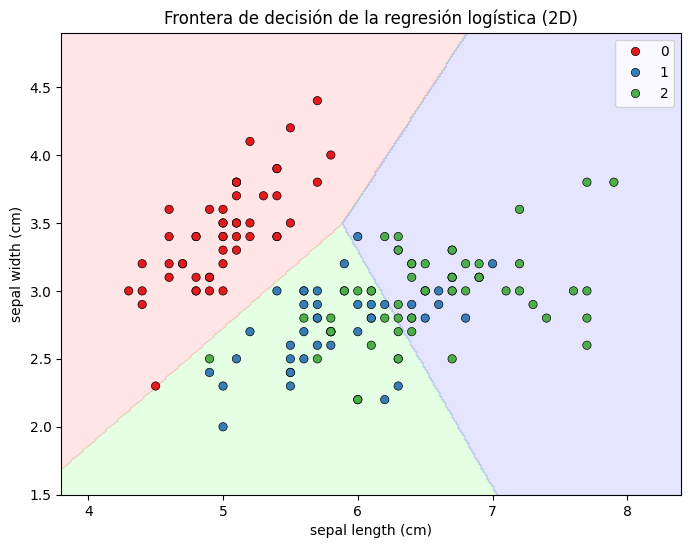

In [8]:
# Visualización de la frontera de decisión (solo 2 características para 2D)
from matplotlib.colors import ListedColormap

X_vis = X[:, :2]
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y, test_size=0.2, random_state=SEED
)
model_vis = LogisticRegression(max_iter=200, random_state=SEED)
model_vis.fit(X_train_vis, y_train_vis)

# Crear malla para graficar la frontera
gx, gy = np.meshgrid(
    np.linspace(X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5, 300),
    np.linspace(X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5, 300)
)
Z = model_vis.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(gx, gy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1], hue=y, palette='Set1', edgecolor='k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Frontera de decisión de la regresión logística (2D)')
plt.show()

## 7. Análisis avanzado

### Efecto de la regularización (parámetro C)

La **regularización** evita el sobreajuste penalizando la complejidad del modelo. En regresión logística, el parámetro `C` controla su intensidad: un valor bajo implica mayor regularización (modelo más simple), un valor alto permite mayor ajuste a los datos.

**Tipos de regularización:**
- **L1 (Lasso):** Penaliza la suma de valores absolutos → tiende a hacer algunos coeficientes exactamente cero (selección automática de variables).
- **L2 (Ridge):** Penaliza la suma de cuadrados → reduce todos los coeficientes, rara vez a cero.
- **Elastic Net:** Combina L1 y L2.

**Truco:** Ajusta `C` con validación cruzada (`GridSearchCV`) para encontrar el valor óptimo.

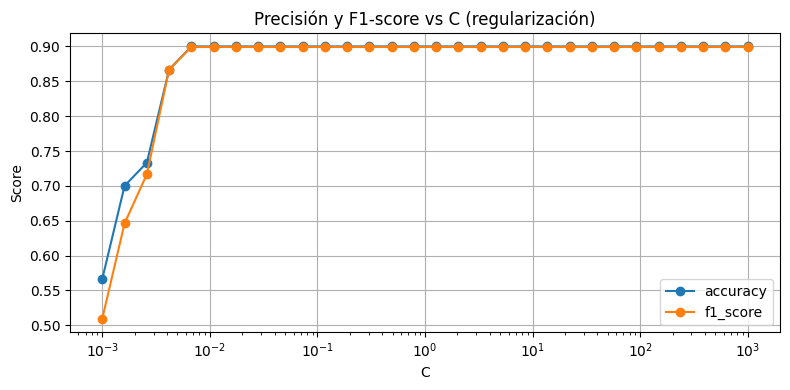

,C,accuracy,f1_score
0,0.0010,0.5667,0.5098
1,0.0016,0.7000,0.6462
2,0.0026,0.7333,0.7167
3,0.0042,0.8667,0.8667
4,0.0067,0.9000,0.8992
5,0.0108,0.9000,0.8992
6,0.0174,0.9000,0.8992
7,0.0281,0.9000,0.8992
8,0.0452,0.9000,0.8992
9,0.0728,0.9000,0.8992


In [9]:
from sklearn.metrics import f1_score

C_values = np.logspace(-3, 3, 30)
scores = []

for C in C_values:
    model_C = LogisticRegression(C=C, max_iter=200, random_state=SEED)
    model_C.fit(X_train_vis, y_train_vis)
    y_pred_C = model_C.predict(X_test_vis)
    acc = accuracy_score(y_test_vis, y_pred_C)
    f1 = f1_score(y_test_vis, y_pred_C, average='weighted')
    scores.append({'C': C, 'accuracy': acc, 'f1_score': f1})

scores_df = pd.DataFrame(scores)
scores_df.plot(x='C', y=['accuracy', 'f1_score'], marker='o', logx=True, figsize=(8, 4))
plt.title('Precisión y F1-score vs C (regularización)')
plt.ylabel('Score')
plt.xlabel('C')
plt.grid(True)
plt.tight_layout()
plt.show()
scores_df.round(4)

**¿Qué se observa?**
- Con **C pequeño** (mucha regularización), la frontera es más rígida → posible subajuste.
- Con **C grande** (poca regularización), el modelo se ajusta más → posible sobreajuste con ruido.

**Truco:** Ajusta `C` con validación cruzada para encontrar el valor óptimo para tu problema.

### Comparación de solvers y efecto del escalado de variables

El parámetro `solver` define el algoritmo de optimización. Algunos solvers requieren que los datos estén escalados para un mejor desempeño. Comparamos distintos solvers con y sin escalado.

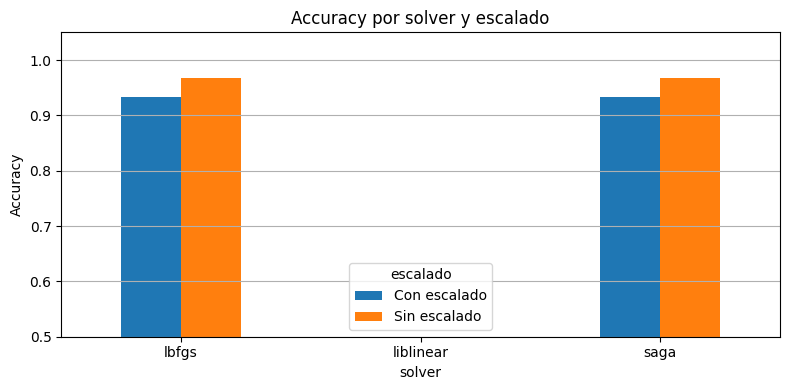

escalado,Con escalado,Sin escalado
solver,,
lbfgs,0.9333,0.9667
liblinear,NaN,NaN
saga,0.9333,0.9667


In [10]:
solvers = ['liblinear', 'lbfgs', 'saga']
results = []

for solver in solvers:
    for scaled, label in [(False, 'Sin escalado'), (True, 'Con escalado')]:
        X_tr = X_train_scaled if scaled else X_train
        X_te = X_test_scaled if scaled else X_test
        try:
            model_s = LogisticRegression(solver=solver, max_iter=2000, random_state=SEED)
            model_s.fit(X_tr, y_train)
            acc = accuracy_score(y_test, model_s.predict(X_te))
            results.append({'solver': solver, 'escalado': label, 'accuracy': round(acc, 4)})
        except Exception as e:
            results.append({'solver': solver, 'escalado': label, 'accuracy': None})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='solver', columns='escalado', values='accuracy')
pivot.plot(kind='bar', figsize=(8, 4))
plt.title('Accuracy por solver y escalado')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.05)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
pivot

**¿Qué aprendemos?**
- Solvers como `'saga'` y `'lbfgs'` mejoran su desempeño cuando los datos están escalados.
- El escalado es especialmente importante si las variables tienen diferentes rangos.
- `'liblinear'` es robusto para datasets pequeños y funciona bien sin escalado.

**Truco:** Siempre prueba el escalado y compara solvers si tu modelo no converge o la precisión es baja.

---
> #### 🛠️ Buenas prácticas: errores comunes al configurar solvers en sklearn ≥ 1.8

Durante la comparación de solvers y regularización pueden aparecer tres advertencias/errores frecuentes. Aquí se explica qué los causa y cómo corregirlos.

---

**1. `ConvergenceWarning: The max_iter was reached which means the coef_ did not converge`**

*¿Qué pasó?*
El solver `saga` (y otros iterativos) no encontró los coeficientes óptimos dentro del límite de iteraciones. Ocurre en dos situaciones:
- Los datos **no están escalados** → las gradientes tienen magnitudes muy distintas, el solver oscila.
- Se usa **`GridSearchCV` o `cross_val_score`** → cada fold entrena con menos datos (p. ej. 80%), lo que requiere más iteraciones para alcanzar la misma tolerancia.

*¿Cómo se corrige?*
```python
# ❌ Puede no converger con datos sin escalar o en CV
LogisticRegression(solver='saga', max_iter=500)

# ✅ 1. Escalar SIEMPRE antes de entrenar (StandardScaler dentro del Pipeline)
# ✅ 2. Usar max_iter alto y fijarlo explícitamente en el param_grid del GridSearchCV
#        para que aplique en cada fold, no solo en el estimador base
param_grid = [
    {'clf__solver': ['saga'], 'clf__max_iter': [5000], 'clf__C': [0.1, 1, 10]},
]
```

---

**2. `FutureWarning: 'penalty' was deprecated in version 1.8`**

*¿Qué pasó?*
El parámetro `penalty='l1'/'l2'` fue deprecado en sklearn 1.8. La nueva API usa `l1_ratio` para controlar el tipo de regularización.

*¿Cómo se corrige?*
```python
# ❌ API antigua (sklearn < 1.8) — genera FutureWarning en versiones recientes
LogisticRegression(penalty='l1', solver='liblinear')
LogisticRegression(penalty='l2', solver='lbfgs')

# ✅ API nueva (sklearn >= 1.8)
LogisticRegression(l1_ratio=1.0, solver='saga')   # equivale a L1
LogisticRegression(l1_ratio=0.0, solver='lbfgs')  # equivale a L2 (defecto)
LogisticRegression(C=np.inf)                       # equivale a penalty='none'
```

---

**3. `ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3)`**

*¿Qué pasó?*
En sklearn ≥ 1.8, `liblinear` dejó de soportar clasificación multiclase directamente. Solo funciona para problemas **binarios**.

*¿Cómo se corrige?*
```python
# ❌ liblinear con 3+ clases → ValueError en sklearn >= 1.8
LogisticRegression(solver='liblinear').fit(X, y)  # y tiene 3 clases

# ✅ Opción 1: usar lbfgs o saga (soportan multiclase nativamente)
LogisticRegression(solver='lbfgs', max_iter=5000)
LogisticRegression(solver='saga',  max_iter=5000)

# ✅ Opción 2: envolver con OneVsRestClassifier si se quiere mantener liblinear
from sklearn.multiclass import OneVsRestClassifier
OneVsRestClassifier(LogisticRegression(solver='liblinear'))
```

---

**Tabla resumen de compatibilidad (sklearn ≥ 1.8):**

| Solver | Multiclase | L1 (`l1_ratio=1`) | L2 (`l1_ratio=0`) | ElasticNet | Notas |
|--------|:----------:|:-----------------:|:-----------------:|:----------:|-------|
| `liblinear` | ❌ | ✅ | ✅ | ❌ | Solo binario |
| `lbfgs` | ✅ | ❌ | ✅ | ❌ | Rápido, L2 por defecto |
| `saga` | ✅ | ✅ | ✅ | ✅ | Necesita más `max_iter` y escalado |
| `newton-cg` | ✅ | ❌ | ✅ | ❌ | Quasi-Newton, eficiente en multiclase |

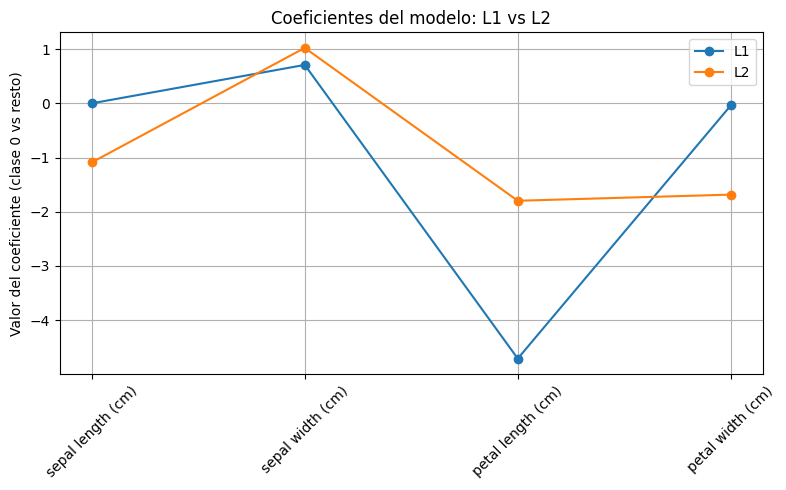

In [11]:
# Comparación de coeficientes L1 vs L2 con API actualizada (sklearn >= 1.8)
# l1_ratio=1.0 → equivale a L1 (Lasso)
# l1_ratio=0.0 → equivale a L2 (Ridge)
configs = [
    {'l1_ratio': 1.0, 'label': 'L1'},
    {'l1_ratio': 0.0, 'label': 'L2'},
]
coefs = {}

for cfg in configs:
    model_p = LogisticRegression(solver='saga', l1_ratio=cfg['l1_ratio'], C=1.0,
                                  max_iter=2000, random_state=SEED)
    model_p.fit(X_train_scaled, y_train)
    coefs[cfg['label']] = model_p.coef_[0]  # coeficientes de la clase 0

plt.figure(figsize=(8, 5))
for label, coef in coefs.items():
    plt.plot(coef, marker='o', label=label)
plt.xticks(range(X.shape[1]), iris.feature_names, rotation=45)
plt.ylabel('Valor del coeficiente (clase 0 vs resto)')
plt.title('Coeficientes del modelo: L1 vs L2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

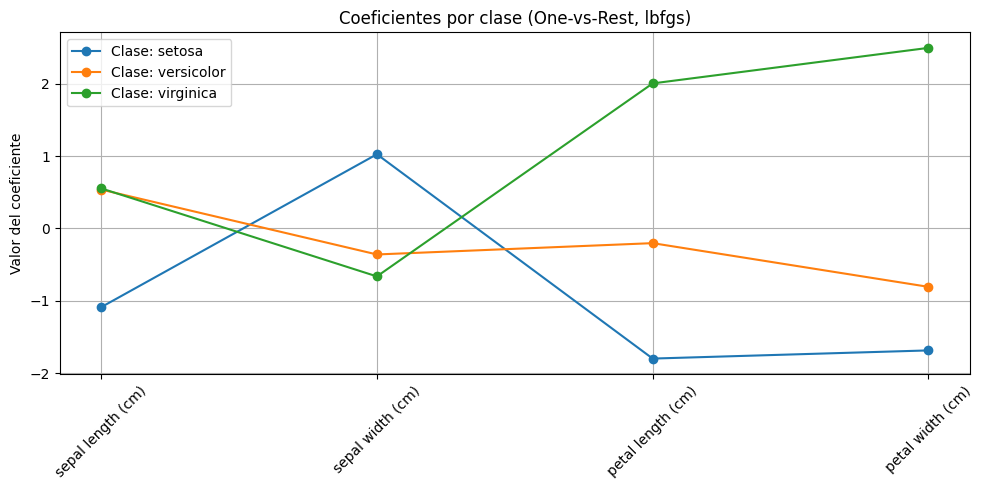

In [12]:
# Modelo multiclase con lbfgs (soporta multiclase nativamente, sklearn >= 1.8)
model_multi = LogisticRegression(solver='lbfgs', C=1.0, max_iter=2000, random_state=SEED)
model_multi.fit(X_train_scaled, y_train)
coefs_multi = model_multi.coef_

plt.figure(figsize=(10, 5))
for i, class_name in enumerate(iris.target_names):
    plt.plot(coefs_multi[i], marker='o', label=f'Clase: {class_name}')
plt.xticks(range(X.shape[1]), iris.feature_names, rotation=45)
plt.ylabel('Valor del coeficiente')
plt.title('Coeficientes por clase (One-vs-Rest, lbfgs)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Validación cruzada para selección de hiperparámetros

La **validación cruzada** (cross-validation) permite estimar el desempeño real del modelo y elegir los mejores hiperparámetros evitando el sobreajuste al conjunto de prueba.

**¿Por qué usar validación cruzada?**
- Estima el desempeño en datos no vistos de forma más confiable que una sola partición.
- Ayuda a elegir hiperparámetros de forma objetiva.

**Truco:** Usa `GridSearchCV` o `RandomizedSearchCV` para automatizar la búsqueda de hiperparámetros.

In [13]:
# Pipeline: escalado + modelo (evita data leakage)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=SEED, max_iter=5000))
])

# Validación cruzada con 5 folds
cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'Accuracy promedio (CV 5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Scores por fold: {cv_scores.round(4)}')

# max_iter se incluye en el constructor del modelo para garantizar convergencia en todos los folds

Accuracy promedio (CV 5-fold): 0.9600 ± 0.0389
Scores por fold: [0.9667 1.     0.9333 0.9    1.    ]


### Predicción probabilística y umbrales

La regresión logística permite obtener probabilidades para cada clase con `predict_proba`. El umbral por defecto es 0.5, pero puede ajustarse según el problema.

**¿Por qué cambiar el umbral?**
- Si quieres priorizar la detección de una clase (mayor recall), baja el umbral.
- Si quieres reducir falsos positivos, sube el umbral.

**Truco:** Usa curvas ROC y AUC para elegir el umbral óptimo según el costo de errores.

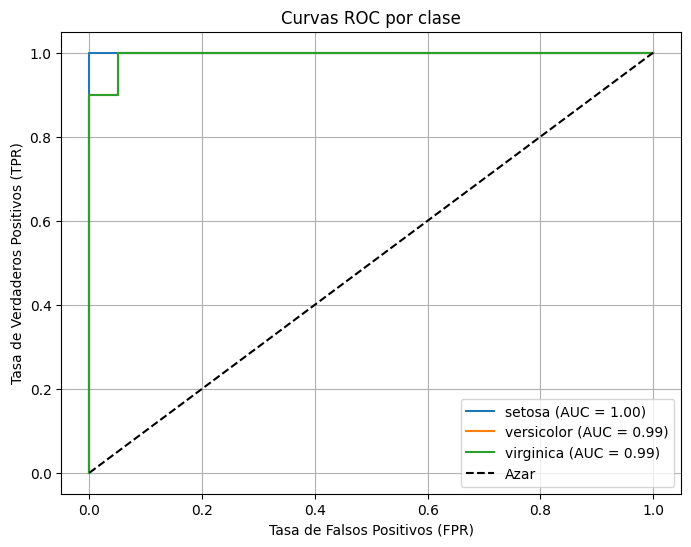

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizamos las clases para ROC multiclase
n_classes = len(iris.target_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
probs_multi = model_multi.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(iris.target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_multi[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC por clase')
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de errores

Analizar los errores del modelo ayuda a identificar patrones, clases difíciles o posibles mejoras en el preprocesamiento.

**¿Qué hacer con los errores?**
- Analiza si hay patrones (ciertas clases, valores extremos, etc.).
- Considera agregar más datos, nuevas variables o modelos más complejos si los errores son sistemáticos.

**Truco:** Visualiza los errores para inspirar nuevas hipótesis o mejoras en el pipeline.

Total de errores: 1 de 30

 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)       real  predicho
               6.7               3.0                5.0               1.7 versicolor virginica


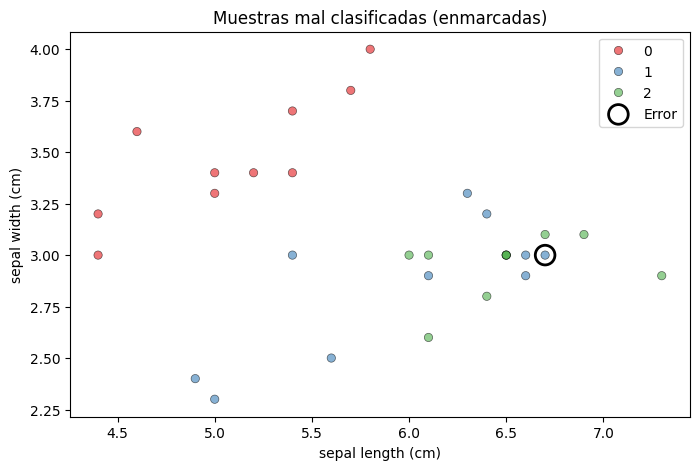

In [15]:
# Identificar muestras mal clasificadas
errors_idx = np.where(y_pred != y_test)[0]
print(f'Total de errores: {len(errors_idx)} de {len(y_test)}')

if len(errors_idx) > 0:
    errors_df = pd.DataFrame(X_test[errors_idx], columns=iris.feature_names)
    errors_df['real'] = [iris.target_names[y_test[i]] for i in errors_idx]
    errors_df['predicho'] = [iris.target_names[y_pred[i]] for i in errors_idx]
    print()
    print(errors_df.to_string(index=False))

    # Visualizar errores en el espacio de las 2 primeras características
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_test,
                    palette='Set1', alpha=0.6, edgecolor='k')
    plt.scatter(X_test[errors_idx, 0], X_test[errors_idx, 1],
                s=200, facecolors='none', edgecolors='black', linewidths=2,
                label='Error', zorder=5)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.title('Muestras mal clasificadas (enmarcadas)')
    plt.legend()
    plt.show()
else:
    print('Sin errores en el conjunto de prueba.')

## 8. Discusión y Conclusiones

- La regresión logística logra una alta precisión en el dataset Iris, siendo un excelente modelo base.
- Es ideal para problemas de clasificación linealmente separables e interpretables.
- El **escalado de datos** y la elección correcta de `solver` y regularización impactan significativamente el desempeño.
- Usar `Pipeline` junto con `GridSearchCV` son **mejores prácticas esenciales** que evitan data leakage y automatizan la búsqueda de hiperparámetros.
- Las **curvas ROC** y el análisis de errores permiten entender mejor el comportamiento del modelo más allá de la accuracy.
- Para problemas más complejos o no lineales, explora los notebooks siguientes (redes neuronales, árboles, etc.).

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Entrena un modelo de regresión logística usando solo 2 variables del dataset Iris. ¿Cambia la accuracy? ¿Por qué?

2. **Ejercicio 2:** Prueba diferentes valores de `C` (0.001, 0.01, 0.1, 1, 10, 100) y grafica la accuracy en train **y** en test. ¿Qué valor produce el mejor equilibrio sesgo-varianza?

3. **Ejercicio 3:** Compara el desempeño del modelo con un `DummyClassifier` (baseline de azar). ¿Cuánto mejora la regresión logística?

4. **Ejercicio 4:** Usa `RandomizedSearchCV` en lugar de `GridSearchCV` para buscar hiperparámetros. ¿Obtienes resultados similares con menos cómputo?

5. **Ejercicio 5:** Visualiza la curva de aprendizaje del modelo con `learning_curve` de scikit-learn. ¿Observas signos de sobreajuste o subajuste?

## 10. Referencias y Recursos

- [Documentación de scikit-learn](https://scikit-learn.org/stable/documentation.html)
- [Regresión logística - scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [Pipeline - scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
- [GridSearchCV - scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [Regresión logística - Wikipedia](https://es.wikipedia.org/wiki/Regresi%C3%B3n_log%C3%ADstica)

---

📎 **Notebook siguiente:** [02. Preprocesamiento y Visualización](./02_preprocesamiento_visualizacion.ipynb)